# Parameter Estimation

This file is used to estimate the parameters for the BKT model given the observations in the pilot

## Imports

In [41]:
#imports
import math
import random
import numpy as np
from typing import List, Tuple
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from typing import List, Dict, Any, Optional
from collections import defaultdict
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## BKT Model

In accordance to Corbett & Anderson (1994) uses Parameters $p_{init}, p_{trans}, p_{slip}$ and $p_{guess}$. So not the classical HMM definition including $B$ (emissions) which would also be unsensical in the current project as forgetting in only nine tasks seems unrealistic.

Also includes forward-backward algorithm and Baum-Welch (EM) to fit the model to a student. However, as I later realized using this would potentially be even harmfull as having only nine tasks is too little to meaningfully fit the model.

Additionally, conditions slip and guess on task difficulty in accordance to Heffernan et al. (2011):
* $P(p_{slip}\mid task)$
* $P(p_{guess}\mid task)$

In [42]:
#class for the BKT implementation
class BKTModel:

    def __init__(self, p_init=0.1, p_trans=0.1, slip=0.1, guess=0.2):
        #set parameters
        self.p_init = float(p_init)
        self.p_trans = float(p_trans)
        self.slip = float(slip)
        self.guess = float(guess)

    #simulate a single student sequence of correctness (0/1)
    #outputs a list of 0/1 of given length representing correctness on tasks (does not allow for reattempts here --> logic in multi-skill BKT)
    def simulate_student(self, length: int, difficulties = None, seed=None) -> List[int]:

        #initate seeds
        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)

        #fill up difficulties if none given (slip and guess is not scaled)
        if difficulties == None:
            difficulties = [1.0 for _ in range(length)]

        #initalize mastery according to p_init    
        if random.random() < self.p_init:
            L = 1 
        else:
            L = 0

        #initalize the observations of the student 
        obs = []
        for t in range(length):

            #get current difficulties and effective slip and guess
            difficulty = difficulties[t]
            effective_slip = min(max(self.slip * difficulty, 1e-6),1-1e-6)
            effective_guess = min(max(self.guess / difficulty, 1e-6),1-1e-6)

            #observation for that the student answers correctly on current question
            if L == 1:
                prob_correct = 1.0 - effective_slip
            else:
                prob_correct = effective_guess

            #sample one observation
            if random.random() < prob_correct:
                c = 1 
            else:
                c = 0
            obs.append(c)

            #do one transition step 
            if L == 0 and random.random() < self.p_trans:
                L = 1

            #if L==1, stay learned (implementation without forgetting since to small sequence lengths, only 9)
        return obs

    #simulate multiple students
    def simulate_dataset(self, n_students: int, seq_len: int, seed=None) -> List[List[int]]:
        if seed is not None:
            random.seed(seed)
        return [self.simulate_student(seq_len) for _ in range(n_students)]

    #function to compute probability of observation c given latent state L (needed for forward-backward)
    #add a dificulty parameter that modifies slip and guess
    def _obs_prob(self, c, L, difficulty=1.0, attempt=1):

        # scale slip and guess by difficulty (Heffernan et al., 2011)
        effective_slip = min(max(self.slip * difficulty, 1e-6), 1-1e-6)
        effective_guess = min(max(self.guess / difficulty, 1e-6), 1-1e-6)

        #condition slip and guess by attempts
        SLIP_GUESS_STEP = 0.1
        effective_slip = min(max(effective_slip * (1 - SLIP_GUESS_STEP * (attempt - 1)), 1e-6), 1-1e-6)
        effective_guess = min(max(effective_guess * (1 + SLIP_GUESS_STEP * (attempt - 1)), 1e-6), 1-1e-6)

        if L == 1:
            if c == 1:
                return (1.0 - effective_slip) 
            else:
                return effective_slip
        else:
            if c == 1:
                return effective_guess 
            else:
                return 1.0 - effective_guess
            
    #Forward-backward (EM) algorithm for HMM --> also only needed when fitting parameters given an observation
    #compute forward and backward messages and posteriors for one sequence.
    #returns alpha, beta, gamma (posterior of L_t=1), xi (expected transitions 0->1 at t)
    def forward_backward(self, seq: List[int], difficulties = List[float], repeats = List[int]) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        
        # set difficulties to 1 if none given
        if difficulties is None:
            difficulties = [1.0 for _ in range(len(seq))]

        #read out the length of the sequence 
        len_seq = len(seq)

        #calculate forward alpha_t(s) = P(C_1..C_t, L_t = s)
        alpha = np.zeros((len_seq, 2))
        # initalize alpha_0
        alpha[0, 1] = self.p_init * self._obs_prob(seq[0], 1, difficulties[0],repeats[0])
        alpha[0, 0] = (1 - self.p_init) * self._obs_prob(seq[0], 0, difficulties[0],repeats[0])

        # forward pass to calculate alpha_t
        for t in range(1, len_seq):
            #observation at time t
            c = seq[t]
            #iterativly apply formula
            #if previous was 1, next is 1 (no forgetting)
            #P(L_t=1) = alpha[t-1,1]*1 + alpha[t-1,0]*p_trans
            alpha[t, 1] = (alpha[t-1,1] * 1.0 + alpha[t-1,0] * self.p_trans) * self._obs_prob(c, 1, difficulties[t],repeats[t])
            #P(L_t=0) = only possible from previous 0 and no learn
            alpha[t, 0] = (alpha[t-1,0] * (1.0 - self.p_trans)) * self._obs_prob(c, 0, difficulties[t],repeats[t])

        #calculate backward beta_t(s) = P(C_t..C_T, L_t = s)
        beta = np.zeros((len_seq, 2))
        #initalize alpha_T
        beta[len_seq-1, :] = 1.0

        #backward pass to calculate beta_t
        for t in range(len_seq-2, -1, -1):

            #observation at time t+1
            c_next = seq[t+1]

            #iterativly apply formula
            #forgetting irrelevant here in backwards
            beta[t, 1] = 1.0 * self._obs_prob(c_next, 1, difficulties[t], repeats[t]) * beta[t+1, 1]
            #for s=0: s'=1 with p_trans and s'=0 with (1-p_trans)
            beta[t, 0] = (self.p_trans * self._obs_prob(c_next, 1, difficulties[t], repeats[t]) * beta[t+1, 1] +
                          (1.0 - self.p_trans) * self._obs_prob(c_next, 0, difficulties[t], repeats[t]) * beta[t+1, 0])
        
        #calculate gamma based on values for alpha and beta (posterior P(L_t = 1 | seq))

        #initalize gamma 
        gamma = np.zeros(len_seq)

        #iterate through sequence to calculate gamma_t according to formula 
        for t in range(len_seq):
            denominator = (alpha[t,0] * beta[t,0]) + (alpha[t,1] * beta[t,1])
            #check if denominator is zero to avoid division by zero
            if denominator == 0:
                gamma[t] = 0.0
            else:
                gamma[t] = (alpha[t,1] * beta[t,1]) / denominator

        # calculate xi: expected nr of transitions from 0->1 at time t (i.e., from L_t=0 to L_{t+1}=1)
        # sum_j xi(i,j) = gamma(i)
        #initalize xi
        xi = np.zeros(len_seq-1)

        #iterate through sequence to calculate xi_t according to formula
        for t in range(len_seq-1):

            #observation at time t+1
            c_next = seq[t+1]

            #according to forward-backward formula:
            # joint prob proportional to alpha[t,0] * P(L_{t+1}=1|L_t=0)=p_trans * P(C_{t+1}|1) * beta[t+1,1]
            nominator = alpha[t,0] * self.p_trans * self._obs_prob(c_next, 1, difficulties[t], repeats[t]) * beta[t+1,1]
            #compute sum over s,s' of alpha[t,s]*P(s->s')*P(obs_{t+1}|s')*beta[t+1,s']
            denominator = (
                alpha[t,0] * ( (1.0-self.p_trans) * self._obs_prob(c_next, 0, difficulties[t], repeats[t]) * beta[t+1,0]
                              + self.p_trans * self._obs_prob(c_next, 1, difficulties[t], repeats[t]) * beta[t+1,1] )
                + alpha[t,1] * (1.0 * self._obs_prob(c_next, 1, difficulties[t], repeats[t]) * beta[t+1,1])
            )

            #check if denominator is zero to avoid division by zero
            if denominator == 0:
                xi[t] = 0.0
            else:
                xi[t] = nominator / denominator

        #return all computed values (only gamma and xi needed for Baum-Welch EM)
        return alpha, beta, gamma, xi

    #helper function to return how many attempts were used for each task
    def get_attempts(self, data):
        counters = defaultdict(int)  #keeps track of how many times we've seen each task_id
        attempts = []
        
        for correct, task_id in data:
            counters[task_id] += 1      #increment count for this task
            attempts.append(counters[task_id])
        
        return attempts
    
    #Fit parameters with EM (Baum-Welch) using multiple sequences (list of lists of 0/1) 
    def fit(self, sequences: List[List[Tuple[int,float]]], difficulties: List[float], n_iters=15, telling=False):
        for it in range(n_iters):
            #initalize variables to accumulate expected counts
            sum_gamma0 = 0.0   # expected times in state 0
            sum_gamma1 = 0.0   #expected times in state 1
            sum_init1 = 0.0  #expected initial state 1
            sum_trans_0_to_1 = 0.0  #expected transitions 0->1
            sum_correct_in_state1 = 0.0 #expected correct responses in state 1
            sum_state1 = 0.0  #expected times in state 1
            sum_correct_in_state0 = 0.0  #expected correct responses in state 0
            sum_state0 = 0.0  # expected times in state 0

            #E-step: compute expected counts
            #iterate through all sequences
            for i, sequence in enumerate(sequences):

                #get the correct results and task difficulties
                seq = [
                    x for (x, _) in sequence
                ]

                seq_difficulties = [
                    difficulties[y] for (_, y) in sequence
                ]

                seq_repeats = self.get_attempts(sequence)


                #ignore if sequence length is zero
                if len(seq) == 0:
                    continue

                #get results from forward-backward and update sums
                alpha, beta, gamma, xi = self.forward_backward(seq, seq_difficulties, seq_repeats)
                
                len_seq = len(seq)
                sum_init1 += gamma[0]
                sum_gamma1 += gamma.sum()
                sum_gamma0 += (len_seq - gamma.sum())
                sum_trans_0_to_1 += xi.sum() #expected transitions
                #expected observation counts
                #for state1: expected number of times in state1 and response correct

                #iterate through current sequence 
                for t, c in enumerate(seq):

                    #update sums according to gamma_t (formulas for expected counts)
                    if gamma[t] > 0:
                        if c == 1:
                            sum_correct_in_state1 += gamma[t]
                        sum_state1 += gamma[t]
                        sum_state0 += (1.0 - gamma[t])
                        if c == 1:
                            sum_correct_in_state0 += (1.0 - gamma[t])
                    else:
                        # gamma[t]==0 --> contribution to state0 only
                        sum_state0 += 1.0
                        if c == 1:
                            sum_correct_in_state0 += 1.0

            #restirict to prevent extreme local maxima (espesically for skill 1)
            p_init_min, p_init_max = 0.05, 0.95
            slip_min, slip_max = 0.01, 0.35
            guess_min, guess_max = 0.01, 0.35
            p_trans_min, p_trans_max = 0.01, 0.5 


            #M-step updates according to formulas 
            new_p_init = (sum_init1 / len(sequences)) if len(sequences) > 0 else self.p_init
            new_p_trans = (sum_trans_0_to_1 / max(1e-8, sum_gamma0))  # expected transitions / expected times in 0
            new_slip = 1.0 - (sum_correct_in_state1 / max(1e-8, sum_state1))
            new_guess = (sum_correct_in_state0 / max(1e-8, sum_state0))
            # clip to avoid degenerate values
            self.p_init = float(min(max(new_p_init, p_init_min), p_init_max))
            self.p_trans = float(min(max(new_p_trans, p_trans_min), p_trans_max))
            self.slip   = float(min(max(new_slip, slip_min), slip_max))
            self.guess  = float(min(max(new_guess, guess_min), guess_max))

            #if telling print out the current vaues of the parameters
            if telling:
                print(f"EM iter {it+1}: p_init={self.p_init:.5f}, p_trans={self.p_trans:.5f}, slip={self.slip:.5f}, guess={self.guess:.5f}")


## Multi Skill BKT Model

**Note**: We do not use Multi Skill BKT as the theoretical background on this is small and it is unnesesary for the current task.

This is a extension to the previously defined simple BKT model that allows that multiple skills are needed for one task. It does so by multplying slip and guess chance conditioned on mastery for both skills (common practice). Additionally, it includes the following extensions to the vanilla BKT model:
1. Incoperates difficulties by conditioning slip and guess on difficulty (Heffernan et al., 2011):
* $P(p_{slip}\mid task)$
* $P(p_{guess}\mid task)$
2. Allows for multiple attempts after inital failure and conditions slip, guess and transition probabilite on this (Bhatt et al., 2020):
* $P(p_{slip}\mid \# attempt)$
* $P(p_{guess}\mid \# attempt)$
* $P(p_{trans}\mid \# attempt)$


In [43]:
#class for the BKT implementation which allows having multiple skills requrired in one task
#includes:
#   imediate retakes until correct or probabilistic retakes that condition slip, guess and transition probabilities
#   task difficulties that condition slip and guess
class MultiSkillBKT:

    #initalize with n_skills BKT models
    def __init__(self, n_skills: int, p_init=0.1, p_trans=0.1, slip=0.1, guess=0.2):
        # Create one BKTModel per skill
        self.skills = [BKTModel(p_init, p_trans, slip, guess) for _ in range(n_skills)]
        self.n_skills = n_skills

    
    # Simulate a student sequence of responses for tasks, allowing retakes.
    # Parameters:
    #   - task_skill_map: List of tasks, each task is a list of skill indices needed for the task
    #   - seed: random seed for reproducibility
    #   - task_difficulties: Optional list of task difficulties (float) for each task
    #   - retake_until_correct: if True, retry wrong attempts until correct or max_retries reached.
    #   - max_retries: maximum number of attempts per task (including first attempt).

    #returns a dictionary with keys:
    #   - 'task' : index in task_skill_map
    #   - 'attempt' : attempt number for that task (1,2,...) 
    #   - 'skills' : list of skill indices required for that task
    #   - 'correct' : 0/1 whether the student answered correctly on that attempt
    #   - 'difficulty' : difficulty of that task
    def simulate_student(self, task_skill_map, seed = None, *, task_difficulties = None, retake_until_correct = False, max_retries = None):
        
        #set seed if given
        if seed is not None:
            random.seed(seed)

        #set task difficulties to 1 if none given
        if task_difficulties is None:
            task_difficulties = [1.0 for _ in range(len(task_skill_map))]

        # initialize per-skill mastery state based on p_init
        L = [1 if random.random() < sk.p_init else 0 for sk in self.skills]
        records: List[Dict[str, Any]] = []

        for task_idx, skills_required in enumerate(task_skill_map):
            attempt = 0
            while True:
                attempt += 1

                # compute probability correct on this attempt (independent slip/guess per skill)
                prob_correct = 1.0 

                for s in skills_required:
                    
                    #condition slip and guess by difficulty
                    effective_slip = min(max(self.skills[s].slip * task_difficulties[task_idx], 1e-6),1-1e-6)
                    effective_guess = min(max(self.skills[s].guess / task_difficulties[task_idx], 1e-6),1-1e-6)

                    #condition slip and guess by attempts 
                    SLIP_GUESS_STEP = 0.1
                    effective_slip = min(max(effective_slip * (1 - SLIP_GUESS_STEP * (attempt - 1)), 1e-6), 1-1e-6)
                    effective_guess = min(max(effective_guess * (1 + SLIP_GUESS_STEP * (attempt - 1)), 1e-6), 1-1e-6)

                    #caluclate prob_correct contribution for that skill
                    if L[s] == 1:
                        prob_correct *= (1.0 - effective_slip)
                    else:
                        prob_correct *= effective_guess

                #sample correctness for this attempt
                if random.random() < prob_correct:
                    c=1
                else:
                    c=0

                #append current attempt record
                records.append({
                    'task': task_idx,
                    'attempt': attempt,
                    'skills': list(skills_required),
                    'correct': c,
                    'difficulty': task_difficulties[task_idx]
                })

                #after each attempt, update mastery for each skill (no forgetting)
                for s in skills_required:

                    P_TRANS_STEP = 0.1

                    #condition p_trans on attempts
                    effective_p_trans = min(self.skills[s].p_trans * (1 + P_TRANS_STEP * (attempt - 1)), 1 - 1e-6)

                    if L[s] == 0 and random.random() < effective_p_trans:
                        L[s] = 1

                #decide whether to retry
                if c == 1:
                    break  #correct --> stop retrying (common policy)
                # if incorrect retry until correct or max_retries reached 
                if retake_until_correct:
                    if max_retries is None:
                        continue
                    elif attempt >= max_retries:
                        break
                    else:
                        continue
                else:
                    # no retakes if set to false
                    break

        return records


## Example simulation

Defines a task skill mapping and difficulties for each task based on pilot participants feedback. This is likely a better indicator than number of fails on task and reduces offerfitting. Afterwards initalizes a multi skill BKT and simulates a students behaviour.

In [44]:
#Example task mapping
task_skill_map = [[0], [1], [0,1], [0], [1], [0,1], [0], [1], [0,1]]
difficulties = [1, 1.1, 0.8, 0.7, 0.7, 0.6, 1, 1.3, 0.6]

#initialize multi-skill BKT
ms_bkt = MultiSkillBKT(n_skills=2, p_init=0.1, p_trans=0.1, slip=0.1, guess=0.2)

# Example: retry until correct, up to 4 attempts
records = ms_bkt.simulate_student(task_skill_map, task_difficulties=difficulties, seed=43, retake_until_correct=True)

#output results 
for r in records:
    print(f"task {r['task']}, attempt {r['attempt']}, skills {r['skills']}, difficulty={r['difficulty']}, correct={r['correct']}")

task 0, attempt 1, skills [0], difficulty=1, correct=1
task 1, attempt 1, skills [1], difficulty=1.1, correct=0
task 1, attempt 2, skills [1], difficulty=1.1, correct=0
task 1, attempt 3, skills [1], difficulty=1.1, correct=0
task 1, attempt 4, skills [1], difficulty=1.1, correct=1
task 2, attempt 1, skills [0, 1], difficulty=0.8, correct=1
task 3, attempt 1, skills [0], difficulty=0.7, correct=1
task 4, attempt 1, skills [1], difficulty=0.7, correct=1
task 5, attempt 1, skills [0, 1], difficulty=0.6, correct=1
task 6, attempt 1, skills [0], difficulty=1, correct=1
task 7, attempt 1, skills [1], difficulty=1.3, correct=1
task 8, attempt 1, skills [0, 1], difficulty=0.6, correct=1


In [45]:
learning_sequences = [
        [(0,0),(0,0),(0,0),(1,0),(0,1),(0,1),(1,1),(1,2),(0,3),(1,3),(0,4),(1,4),(0,5),(1,5),(0,6),(0,6),(1,6),(0,7),(0,7),(0,7),(0,7),(0,7),(0,7),(0,7),(0,7),(0,7),(1,7),(1,8)], # first participant; well at least first in excel
        [(0,0),(1,0),(1,1),(1,2),(0,3),(1,3),(1,4),(1,5),(1,6),(1,7),(1,8)], #second participant
        [(0,0),(1,0),(1,1),(0,2),(1,2),(1,3),(1,4),(0,5),(1,5),(0,6),(0,6),(0,6),(1,6),(0,7),(0,7),(0,7),(0,7),(0,7),(1,7),(1,8)], #third participant
        [(0,0),(1,0),(1,1),(1,2),(0,3),(1,3),(1,4),(1,5),(1,6),(1,7),(1,8)], #fourth participant
        [(1,0),(1,1),(1,2),(0,3),(1,3),(1,4),(1,5),(1,6),(0,7),(1,7),(1,8)], #fifth participant 
        [(0,0),(0,0),(0,0),(1,0),(1,1),(1,2),(1,3),(1,4),(0,5),(1,5),(1,6),(1,7),(1,8)], #sixth participant
        [(1,0),(1,1),(1,2),(1,3),(1,4),(0,5),(0,5),(0,5),(0,5),(0,5),(1,5),(1,6),(1,7),(1,8)], #seventh participant
        [(0,0),(0,0),(0,0),(0,0),(0,0),(1,0),(0,1),(0,1),(1,1),(0,2),(0,2),(1,2),(0,3),(0,3),(0,3),(0,3),(0,3),(0,3),(0,3),(0,3),(0,3),(0,3),(1,3),(1,4),(0,5),(1,5),(0,6),(1,6),(0,7),(0,7),(0,7),(0,7),(0,7),(0,7),(0,7),(1,7),(1,8)], #eight participant
        [(1,0),(1,1),(1,2),(0,3),(0,3),(1,3),(1,4),(1,5),(1,6),(0,7),(1,7),(1,8)] #ninth participant
    ]

## Get BKT parameters

Use the data collected in the first pilot to get the most likely BKT parameters 

We have to take care of the following two issues: 
1) We can have multiple attempts on the same task --> we can just have them treat the repeated attempt as new task (does not violate any assumtion)
2) We assume for fitting parameters that each task is equally hard
3) We treat each skill as seperate since in the given setup [0,1], [0,1], [0,1],[0,2], [0,2], [0,2],[0,3], [0,3], [0,3] all skills are conditionally independent of each other with exception of 0 which will be better estimated since it has more observations

In [46]:
#setup learning sequence in the form [(0,0),(correct?,subtask(1-9))]  --> the requried skill can be infered from the subtask
learning_sequences = [
        [(0,0),(0,0),(0,0),(1,0),(0,1),(0,1),(1,1),(1,2),(0,3),(1,3),(0,4),(1,4),(0,5),(1,5),(0,6),(0,6),(1,6),(0,7),(0,7),(0,7),(0,7),(0,7),(0,7),(0,7),(0,7),(0,7),(1,7),(1,8)], # first participant; well at least first in excel
        [(0,0),(1,0),(1,1),(1,2),(0,3),(1,3),(1,4),(1,5),(1,6),(1,7),(1,8)], #second participant
        [(0,0),(1,0),(1,1),(0,2),(1,2),(1,3),(1,4),(0,5),(1,5),(0,6),(0,6),(0,6),(1,6),(0,7),(0,7),(0,7),(0,7),(0,7),(1,7),(1,8)], #third participant
        [(0,0),(1,0),(1,1),(1,2),(0,3),(1,3),(1,4),(1,5),(1,6),(1,7),(1,8)], #fourth participant
        [(1,0),(1,1),(1,2),(0,3),(1,3),(1,4),(1,5),(1,6),(0,7),(1,7),(1,8)], #fifth participant 
        [(0,0),(0,0),(0,0),(1,0),(1,1),(1,2),(1,3),(1,4),(0,5),(1,5),(1,6),(1,7),(1,8)], #sixth participant
        [(1,0),(1,1),(1,2),(1,3),(1,4),(0,5),(0,5),(0,5),(0,5),(0,5),(1,5),(1,6),(1,7),(1,8)], #seventh participant
        [(0,0),(0,0),(0,0),(0,0),(0,0),(1,0),(0,1),(0,1),(1,1),(0,2),(0,2),(1,2),(0,3),(0,3),(0,3),(0,3),(0,3),(0,3),(0,3),(0,3),(0,3),(0,3),(1,3),(1,4),(0,5),(1,5),(0,6),(1,6),(0,7),(0,7),(0,7),(0,7),(0,7),(0,7),(0,7),(1,7),(1,8)], #eight participant
        [(1,0),(1,1),(1,2),(0,3),(0,3),(1,3),(1,4),(1,5),(1,6),(0,7),(1,7),(1,8)] #ninth participant
    ]

#holds the difficultie as informed by pilots --> index is here equal to subtask 
difficulties = [1.1, 1.2, 0.9, 0.9, 0.9, 0.8, 1.1, 1.3, 0.7]


#fits one BKT model per skill using per-student attempt sequences
def fit_bkt_per_skill(
    learning_sequences: List[Tuple[int, int]],
    n_skills: int,
    difficulties: List[int] = None,
    *,
    n_iters: int = 20,
    p_init=0.05,
    p_trans=0.1,
    slip=0.1,
    guess=0.2
):

    #Build per-skill, per-student sequences
    #skill_sequences[s] = list of student sequences for skill s
    skill_sequences = [[] for _ in range(n_skills)]

    for student_seq in learning_sequences:
        #initialize empty sequence for this student for each skill
        student_skill_seqs = [[] for _ in range(n_skills)]

        for correct, subtask in student_seq:
            if 0<=subtask<=2:
                skill = 0
            elif 3<=subtask<=5:
                skill = 1
            elif 6<=subtask<=8:
                skill = 2
            else:
                raise RuntimeWarning()
            student_skill_seqs[skill].append((correct,subtask))

        #append non-empty sequences to global skill list
        for s in range(n_skills):
            if student_skill_seqs[s]:
                skill_sequences[s].append(student_skill_seqs[s])

    #2. Fit one BKT per skill using EM 
    skill_models = []
    for s in range(n_skills):

        #intialize model
        model = BKTModel(p_init=p_init, p_trans=p_trans, slip=slip, guess=guess)

        print(skill_sequences[s])

        model.fit(skill_sequences[s], difficulties=difficulties, n_iters=n_iters)
        skill_models.append(model)

    return skill_models

#return the fitted bkt models
models = fit_bkt_per_skill(
    learning_sequences,
    difficulties=difficulties,
    n_skills=3,
    n_iters=25
)

#take into account that skill 0 was not used in the end as it was decided to assume one skill is used per task
print("Most likely parameters (local maxima): ")
for i, m in enumerate(models):
    print(
        f"Skill {i}: "
        f"p_init={m.p_init:.3f}, "
        f"p_trans={m.p_trans:.3f}, "
        f"slip={m.slip:.3f}, "
        f"guess={m.guess:.3f}"
    )

[[(0, 0), (0, 0), (0, 0), (1, 0), (0, 1), (0, 1), (1, 1), (1, 2)], [(0, 0), (1, 0), (1, 1), (1, 2)], [(0, 0), (1, 0), (1, 1), (0, 2), (1, 2)], [(0, 0), (1, 0), (1, 1), (1, 2)], [(1, 0), (1, 1), (1, 2)], [(0, 0), (0, 0), (0, 0), (1, 0), (1, 1), (1, 2)], [(1, 0), (1, 1), (1, 2)], [(0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (1, 0), (0, 1), (0, 1), (1, 1), (0, 2), (0, 2), (1, 2)], [(1, 0), (1, 1), (1, 2)]]
[[(0, 3), (1, 3), (0, 4), (1, 4), (0, 5), (1, 5)], [(0, 3), (1, 3), (1, 4), (1, 5)], [(1, 3), (1, 4), (0, 5), (1, 5)], [(0, 3), (1, 3), (1, 4), (1, 5)], [(0, 3), (1, 3), (1, 4), (1, 5)], [(1, 3), (1, 4), (0, 5), (1, 5)], [(1, 3), (1, 4), (0, 5), (0, 5), (0, 5), (0, 5), (0, 5), (1, 5)], [(0, 3), (0, 3), (0, 3), (0, 3), (0, 3), (0, 3), (0, 3), (0, 3), (0, 3), (0, 3), (1, 3), (1, 4), (0, 5), (1, 5)], [(0, 3), (0, 3), (1, 3), (1, 4), (1, 5)]]
[[(0, 6), (0, 6), (1, 6), (0, 7), (0, 7), (0, 7), (0, 7), (0, 7), (0, 7), (0, 7), (0, 7), (0, 7), (1, 7), (1, 8)], [(1, 6), (1, 7), (1, 8)], [(0, 6), (0, 

### Verify values match with actual expxeriment

In [47]:
#import data
df = pd.read_csv("anonymized_data.csv")
filtered_df = df[df["test_type"] == "RL"]

#map column subfixes to subtask indices (matching cell 11 convention)
subtask_cols = [
    ('task1_1', 0), ('task1_2', 1), ('task1_3', 2),
    ('task2_1', 3), ('task2_2', 4), ('task2_3', 5),
    ('task3_1', 6), ('task3_2', 7), ('task3_3', 8),
]

#construct he learning sequence from the csv
#for each participant: n failures followed by 1 success per subtask, in order
learning_sequences = []
for _, row in filtered_df.iterrows():
    seq = []
    for col_suffix, subtask_idx in subtask_cols:
        n_failed = int(row[f'times_failed_{col_suffix}'])
        seq.extend([(0, subtask_idx)] * n_failed)
        seq.append((1, subtask_idx))
    learning_sequences.append(seq)



#calculate the fitted bkt models
models = fit_bkt_per_skill(
    learning_sequences,
    difficulties=difficulties,
    n_skills=3,
    n_iters=25
)

#take into account that skill 0 was not used in the end as it was decided to assume one skill is used per task
print("Most likely parameters (local maxima): ")
for i, m in enumerate(models):
    print(
        f"Skill {i}: "
        f"p_init={m.p_init:.3f}, "
        f"p_trans={m.p_trans:.3f}, "
        f"slip={m.slip:.3f}, "
        f"guess={m.guess:.3f}"
    )

[[(0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (1, 0), (0, 1), (1, 1), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (1, 2)], [(0, 0), (0, 0), (1, 0), (1, 1), (1, 2)], [(0, 0), (0, 0), (0, 0), (1, 0), (0, 1), (0, 1), (1, 1), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (1, 2)], [(1, 0), (0, 1), (0, 1), (1, 1), (1, 2)], [(0, 0), (0, 0), (1, 0), (1, 1), (1, 2)], [(0, 0), (0, 0), (1, 0), (0, 1), (0, 1), (0, 1), (1, 1), (0, 2), (0, 2), (1, 2)], [(0, 0), (0, 0), (1, 0), (1, 1), (1, 2)], [(0, 0), (0, 0), (1, 0), (0, 1), (0, 1), (1, 1), (1, 2)], [(0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (0, 0), (1, 0), (0, 1), (0, 1), (1, 1), (0, 2), (0, 2), (0, 2), (0, 2), (0, 2), (1, 2)], [(0, 0), (0, 0), (1, 0), (0, 1), (1, 1), (1, 2)], [(0, 0), (1, 0), (1, 1), (1, 2)], [(1, 0), (0, 1), (1, 1), (0, 2), (1, 2)], [(0, 0), (1, 0), (1, 1), (1, 2)], [(1, 0), (0, 1), (0, 1), (0, 1), (1, 1), (1, 2)], [(0, 0), (1, 0), (1, 1), (1, 2)], [(1, 0), (1, 1), (1, 2)], [(1, 0), (0, 1), (1, 1), (1, 2)], [(0, 

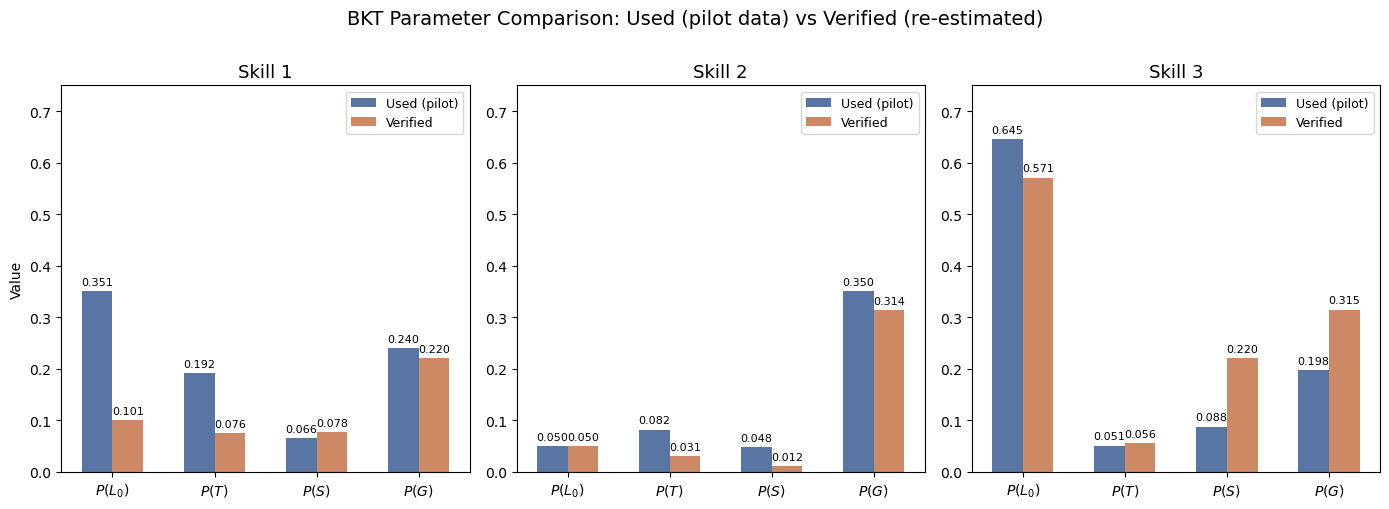

In [48]:
#compare the bkt models
params_used = {
    "Skill 1": {r"$P(L_0)$": 0.351, r"$P(T)$": 0.192, r"$P(S)$": 0.066, r"$P(G)$": 0.240},
    "Skill 2": {r"$P(L_0)$": 0.050, r"$P(T)$": 0.082, r"$P(S)$": 0.048, r"$P(G)$": 0.350},
    "Skill 3": {r"$P(L_0)$": 0.645, r"$P(T)$": 0.051, r"$P(S)$": 0.088, r"$P(G)$": 0.198},
}

params_verified = {
    "Skill 1": {r"$P(L_0)$": 0.101, r"$P(T)$": 0.076, r"$P(S)$": 0.078, r"$P(G)$": 0.220},
    "Skill 2": {r"$P(L_0)$": 0.050, r"$P(T)$": 0.031, r"$P(S)$": 0.012, r"$P(G)$": 0.314},
    "Skill 3": {r"$P(L_0)$": 0.571, r"$P(T)$": 0.056, r"$P(S)$": 0.220, r"$P(G)$": 0.315},
}

#create new df for easy plotting purposes
rows = []
for skill in params_used:
    for param, val in params_used[skill].items():
        rows.append({"Skill": skill, "Parameter": param, "Value": val, "Source": "Used (pilot)"})
    for param, val in params_verified[skill].items():
        rows.append({"Skill": skill, "Parameter": param, "Value": val, "Source": "Verified"})

df_plot = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
palette = {"Used (pilot)": "#4C72B0", "Verified": "#DD8452"}

#iterate over skills and plot
for ax, skill in zip(axes, ["Skill 1", "Skill 2", "Skill 3"]):
    data = df_plot[df_plot["Skill"] == skill]
    sns.barplot(data=data, x="Parameter", y="Value", hue="Source",
                palette=palette, ax=ax, width=0.6)
    ax.set_title(skill, fontsize=13)
    ax.set_xlabel("")
    ax.set_ylim(0, 0.75)
    ax.set_ylabel("Value" if ax == axes[0] else "")
    ax.legend(title="", fontsize=9)
    ax.tick_params(axis="x", labelsize=10)
    for bar in ax.patches:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f"{height:.3f}",
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha="center", va="bottom", fontsize=8)

fig.suptitle("BKT Parameter Comparison: Used (pilot data) vs Verified (re-estimated)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("bkt_parameter_comparison.png", dpi=150, bbox_inches="tight")
plt.show()